# Boston Housing Price Predictor - Exploratory Data Analysis

**Course:** ML 60  <br>
**Project:** Boston Housing Price Prediction  <br>
**Purpose:** Explore the dataset, understand the features, visualize relationships, and justify model choices before building the web app. <br>
**Author:** Neelabho Chakraborty 

---

## Dataset Source

The dataset used in this project is the Boston Housing Dataset, originally published by Harrison and Rubinfeld (1978).  
(Loaded from OpenML in this notebook)

**Direct dataset link:** https://www.openml.org/search?type=data&status=active&id=531

**Kaggle mirror (CSV download):** https://www.kaggle.com/datasets/vikrishnan/boston-house-prices

---

## What This Notebook Covers

1. Loading the dataset & checking structure 
2. Check for missing values and data types  
3. Summary statistics for all features  
4. Distribution plots for every feature  
5. Correlation heatmap  
6. Scatter plots: key features vs price  
7. Outlier analysis  
8. Feature scaling demonstration  
9. Train three models and compare results  
10. Feature importance chart  
11. Actual vs predicted plot  
12. Final summary and conclusions

---

## Feature Reference Table

| Feature | Description |
|---------|-------------|
| CRIM | Per capita crime rate by town |
| ZN | Proportion of residential land zoned for lots over 25,000 sq ft |
| INDUS | Proportion of non-retail business acres per town |
| CHAS | Charles River dummy variable (1 if tract bounds river, 0 if not) |
| NOX | Nitric oxides concentration (parts per 10 million) |
| RM | Average number of rooms per dwelling |
| AGE | Proportion of owner-occupied units built before 1940 |
| DIS | Weighted distances to five Boston employment centres |
| RAD | Index of accessibility to radial highways |
| TAX | Full-value property tax rate per $10,000 |
| PTRATIO | Pupil-teacher ratio by town |
| B | 1000(Bk - 0.63)^2 where Bk is proportion of Black residents |
| LSTAT | Percentage of lower-status population |
| MEDV | Median value of owner-occupied homes in $1000s (TARGET) |

---
## Environment setup

Run this cell first!  


In [1]:
# If any library is missing, uncomment the line below and run it once
# !pip install scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

warnings.filterwarnings('ignore')

# Global plot styling - applies to all charts in this notebook
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('All libraries imported successfully.')
print('numpy version  :', np.__version__)
print('pandas version :', pd.__version__)

All libraries imported successfully.
numpy version  : 2.4.4
pandas version : 3.0.2


---
## Loading the Dataset


In [2]:
print('Loading Boston Housing dataset from OpenML...')
print('Dataset URL: https://www.openml.org/search?type=data&status=active&id=531')
print()

boston = fetch_openml(name='boston', version=1, as_frame=True)

# Combine features and target into one DataFrame for easy exploration
df = boston.frame.copy()

# Ensure all columns are numeric (OpenML sometimes loads them as object type)
df = df.apply(pd.to_numeric, errors='coerce')

print('Dataset loaded.')
print('Shape: {} rows x {} columns'.format(df.shape[0], df.shape[1]))
print()
print('Column names:')
print(list(df.columns))

Loading Boston Housing dataset from OpenML...
Dataset URL: https://www.openml.org/search?type=data&status=active&id=531

Dataset loaded.
Shape: 506 rows x 14 columns

Column names:
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


In [3]:
print('First 5 rows:')
df.head()

First 5 rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
print('Last 5 rows:')
df.tail()

Last 5 rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273.0,21.0,396.90,7.88,11.9


---
## Structure of datatypes in dataset

df.info() shows:
- The data type of each column (float64 = decimal number, int64 = integer)
- How many non-null values each column has (missing values would show a lower count)
- Total memory used by the DataFrame

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [ ]:
#Check missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print()
if missing.sum() == 0:
    print('No missing values found. The dataset is clean.')
else:
    print('WARNING: Missing values detected. Handle them before training.')

Missing values per column:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

No missing values found. The dataset is clean.


---
## Summary Statistics

df.describe() computes 8 statistics for every column:
- count: number of non-missing values
- mean: average value
- std: standard deviation (how spread out the values are)
- min / max: lowest and highest values
- 25%, 50%, 75%: the quartile values (50% = median)
.

In [7]:
pd.set_option('display.float_format', '{:.3f}'.format)
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000
mean,3.614,11.364,11.137,0.069,0.555,6.285,68.575,3.795,9.549,408.237,18.456,356.674,12.653,22.533
std,8.602,23.322,6.860,0.254,0.116,0.703,28.149,2.106,8.707,168.537,2.165,91.295,7.141,9.197
min,0.006,0.000,0.460,0.000,0.385,3.561,2.900,1.130,1.000,187.000,12.600,0.320,1.730,5.000
25%,0.082,0.000,5.190,0.000,0.449,5.885,45.025,2.100,4.000,279.000,17.400,375.377,6.950,17.025
50%,0.257,0.000,9.690,0.000,0.538,6.208,77.500,3.207,5.000,330.000,19.050,391.440,11.360,21.200
75%,3.677,12.500,18.100,0.000,0.624,6.623,94.075,5.188,24.000,666.000,20.200,396.225,16.955,25.000
max,88.976,100.000,27.740,1.000,0.871,8.780,100.000,12.127,24.000,711.000,22.000,396.900,37.970,50.000


---
## Target Variable Distribution

Before looking at features, understand the **target variable MEDV (price)**.  
A histogram shows the distribution of prices across all 506 neighborhoods.  
The red dashed line marks the mean price.  


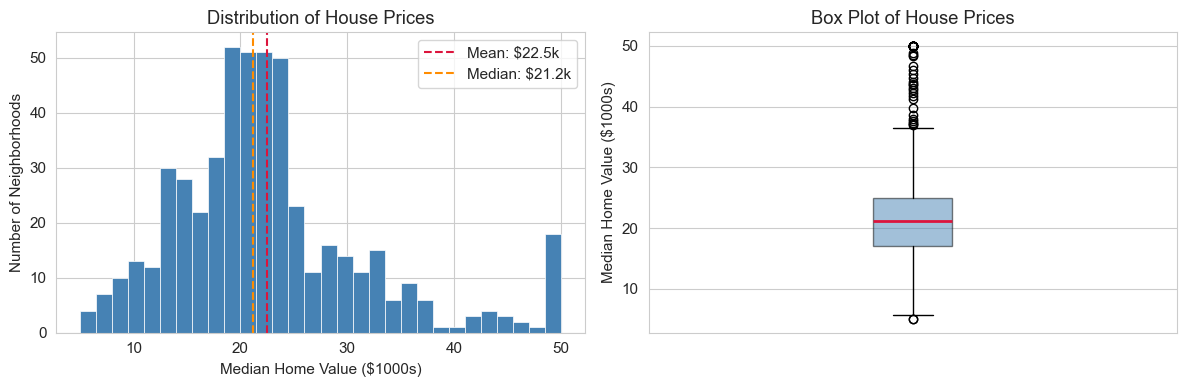

Price statistics:
  Mean   : $22.53k
  Median : $21.20k
  Std    : $9.20k
  Min    : $5.00k
  Max    : $50.00k


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['MEDV'], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['MEDV'].mean(), color='crimson', linestyle='--', linewidth=1.5, label='Mean: ${:.1f}k'.format(df['MEDV'].mean()))
axes[0].axvline(df['MEDV'].median(), color='darkorange', linestyle='--', linewidth=1.5, label='Median: ${:.1f}k'.format(df['MEDV'].median()))
axes[0].set_xlabel('Median Home Value ($1000s)')
axes[0].set_ylabel('Number of Neighborhoods')
axes[0].set_title('Distribution of House Prices')
axes[0].legend()

# Box plot
axes[1].boxplot(df['MEDV'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5),
                medianprops=dict(color='crimson', linewidth=2))
axes[1].set_ylabel('Median Home Value ($1000s)')
axes[1].set_title('Box Plot of House Prices')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('plot_target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print('Price statistics:')
print('  Mean   : ${:.2f}k'.format(df['MEDV'].mean()))
print('  Median : ${:.2f}k'.format(df['MEDV'].median()))
print('  Std    : ${:.2f}k'.format(df['MEDV'].std()))
print('  Min    : ${:.2f}k'.format(df['MEDV'].min()))
print('  Max    : ${:.2f}k'.format(df['MEDV'].max()))

---
## Distribution of All Features

This plots a histogram for every one of the 13 features in a grid layout.  
Each histogram shows how that feature's values are distributed across all 506 neighborhoods.


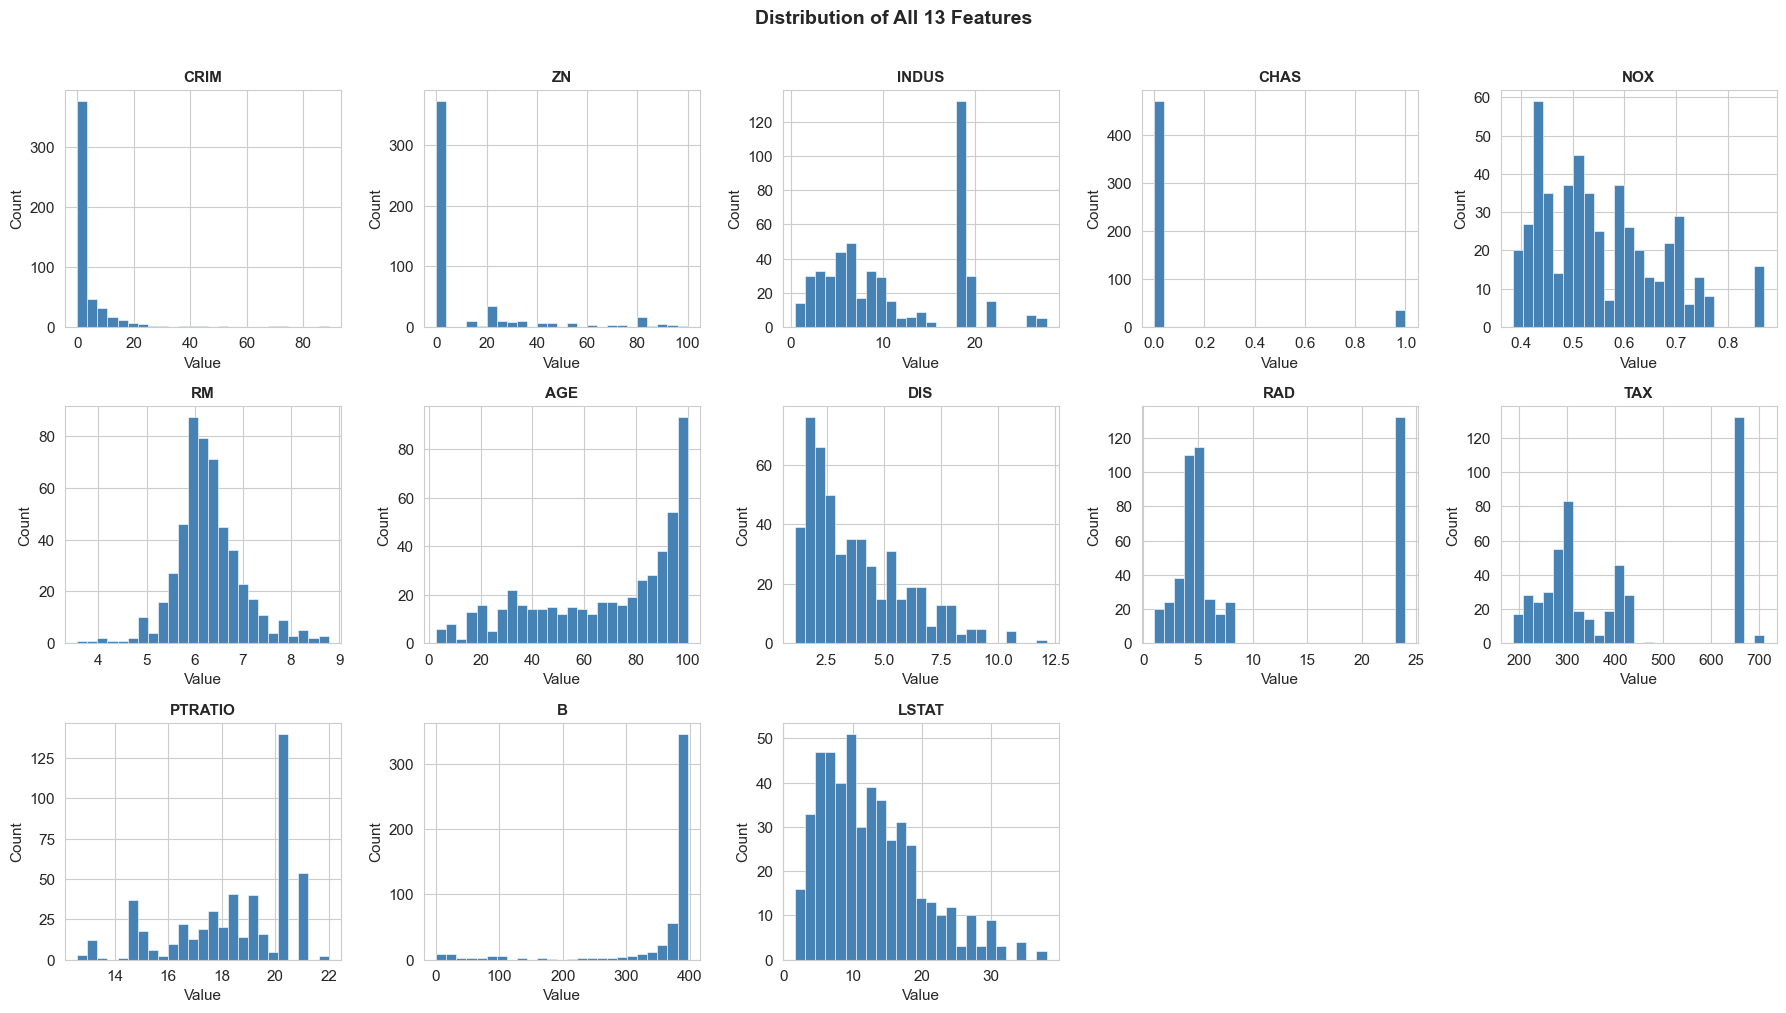

In [9]:
features = [col for col in df.columns if col != 'MEDV']

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=25, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[i].set_title(feature, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# Hide the two unused subplot slots (13 features, but 3x5 grid = 15 slots)
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of All 13 Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

From this we observe:

- CRIM is heavily right-skewed - most neighborhoods have low crime but a few have very high crime
- ZN has many zeros - most tracts have no large-lot residential zoning
- CHAS is binary - almost all tracts are 0 (not bordering the river)
- RAD and TAX show bimodal distributions - two separate groups of neighborhoods

---
## Correlation Heatmap

A correlation heatmap shows the linear relationship between every pair of columns.

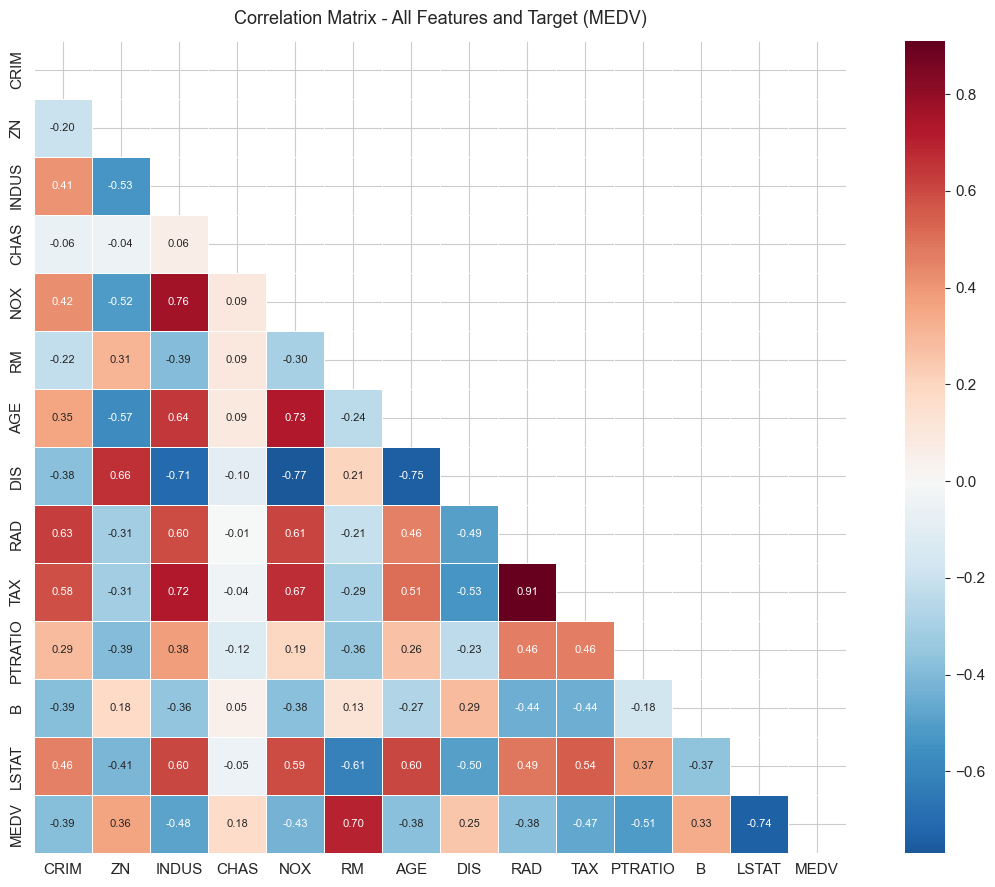

Correlation of each feature with MEDV (house price):
(Sorted from strongest negative to strongest positive)

  LSTAT       -0.738  ##############  negative
  PTRATIO     -0.508  ##########  negative
  INDUS       -0.484  #########  negative
  TAX         -0.469  #########  negative
  NOX         -0.427  ########  negative
  CRIM        -0.388  #######  negative
  RAD         -0.382  #######  negative
  AGE         -0.377  #######  negative
  CHAS        +0.175  ###  positive
  DIS         +0.250  ####  positive
  B           +0.333  ######  positive
  ZN          +0.360  #######  positive
  RM          +0.695  #############  positive


In [10]:
correlation_matrix = df.corr()

plt.figure(figsize=(12, 9))

# Create a mask for the upper triangle so we only show the lower half (avoids duplicate info)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,           # Show the correlation number inside each cell
    fmt='.2f',            # Round to 2 decimal places
    cmap='RdBu_r',        # Red = positive, Blue = negative
    center=0,             # White = 0 correlation
    square=True,
    linewidths=0.4,
    annot_kws={'size': 8}
)

plt.title('Correlation Matrix - All Features and Target (MEDV)', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# Print correlations with MEDV sorted from strongest to weakest
print('Correlation of each feature with MEDV (house price):')
print('(Sorted from strongest negative to strongest positive)')
print()
corr_with_target = correlation_matrix['MEDV'].drop('MEDV').sort_values()
for feature, corr in corr_with_target.items():
    bar = '#' * int(abs(corr) * 20)
    direction = 'negative' if corr < 0 else 'positive'
    print('  {:10s}  {:+.3f}  {}  {}'.format(feature, corr, bar, direction))

Observations:

The last row/column (MEDV) is most important - it shows which features are most strongly related to price.

Key correlations with MEDV:
- RM (rooms): strong positive +0.70 - more rooms, higher price
- LSTAT (poverty %): strong negative -0.74 - higher poverty, lower price
- PTRATIO (school quality): moderate negative -0.51
- NOX (air pollution): moderate negative -0.43

---
##  Key Feature Scatter Plots vs Price

Scatter plots show the relationship between individual features and the target (MEDV) visually.
Each dot is one of the 506 neighborhoods.
The red line is a linear trend line fitted through the points.

We plot the 6 features most correlated with price:
RM, LSTAT, PTRATIO, INDUS, NOX, and CRIM.

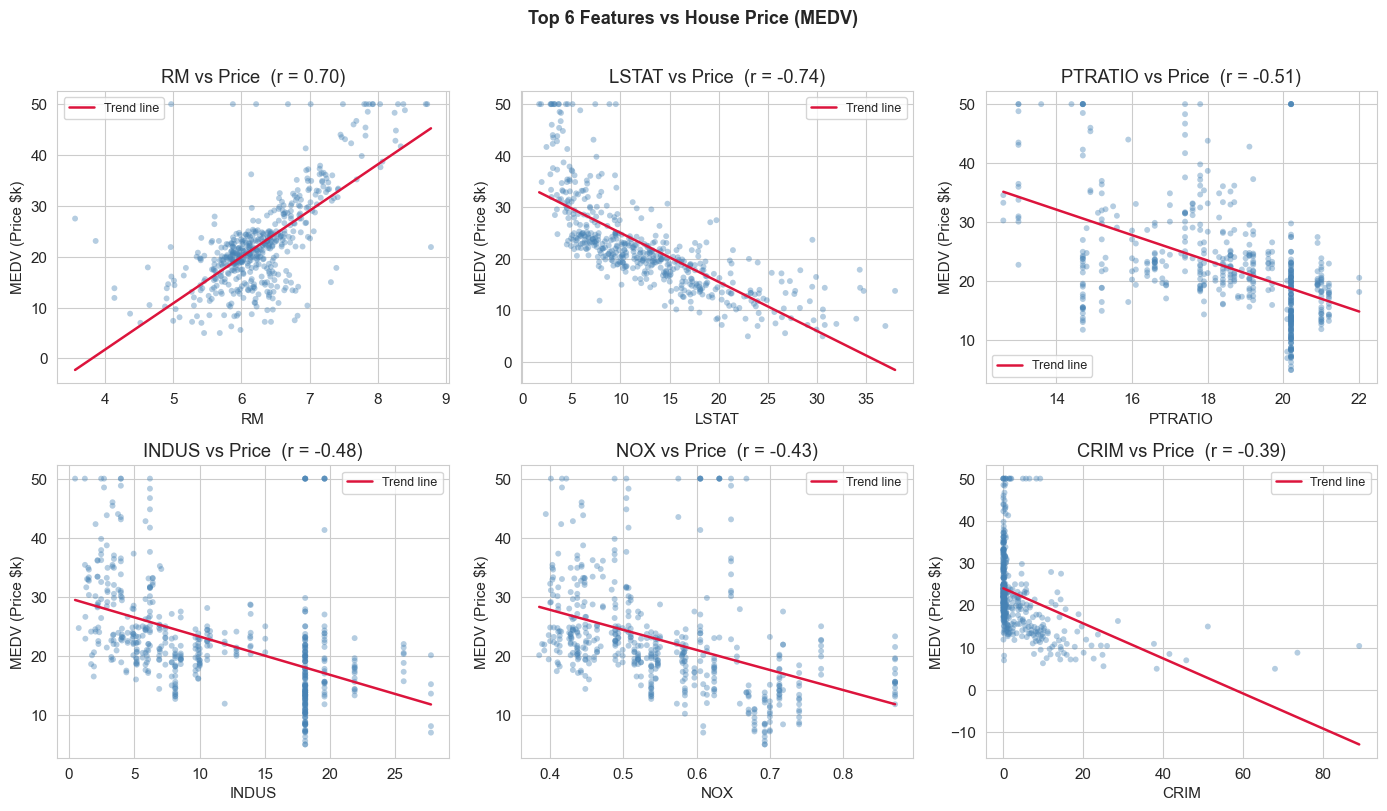

In [11]:
top_features = ['RM', 'LSTAT', 'PTRATIO', 'INDUS', 'NOX', 'CRIM']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    x = df[feature]
    y = df['MEDV']

    # Scatter plot
    axes[i].scatter(x, y, alpha=0.4, s=18, color='steelblue', edgecolors='none')

    # Linear trend line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    axes[i].plot(x_line, p(x_line), color='crimson', linewidth=1.8, label='Trend line')

    corr_val = df[feature].corr(df['MEDV'])
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('MEDV (Price $k)')
    axes[i].set_title('{} vs Price  (r = {:.2f})'.format(feature, corr_val))
    axes[i].legend(fontsize=9)

plt.suptitle('Top 6 Features vs House Price (MEDV)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_scatter_vs_price.png', dpi=120, bbox_inches='tight')
plt.show()

---
##  CHAS (River Boundary) Effect on Price

CHAS is a binary feature: 1 if the tract borders the Charles River, 0 if not.
Because it only has two values, a scatter plot is not useful.
Instead we use box plots to compare the price distribution between the two groups.


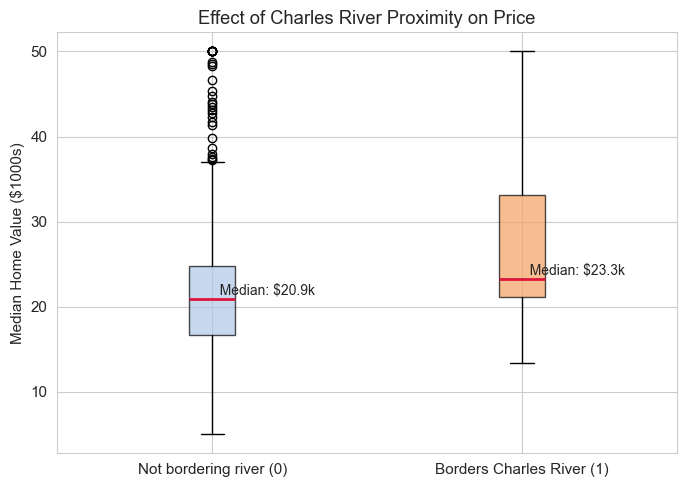

Group 0 (not bordering river) - count: 471  median: $20.9k
Group 1 (borders river)       - count: 35  median: $23.3k


In [12]:
fig, ax = plt.subplots(figsize=(7, 5))

group_0 = df[df['CHAS'] == 0]['MEDV']
group_1 = df[df['CHAS'] == 1]['MEDV']

bp = ax.boxplot(
    [group_0, group_1],
    labels=['Not bordering river (0)', 'Borders Charles River (1)'],
    patch_artist=True,
    medianprops=dict(color='crimson', linewidth=2)
)

colors = ['#aec6e8', '#f4a261']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Median Home Value ($1000s)')
ax.set_title('Effect of Charles River Proximity on Price')

# Annotate with median values
ax.text(1, group_0.median() + 0.5, '  Median: ${:.1f}k'.format(group_0.median()), fontsize=10)
ax.text(2, group_1.median() + 0.5, '  Median: ${:.1f}k'.format(group_1.median()), fontsize=10)

plt.tight_layout()
plt.savefig('plot_chas_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()

print('Group 0 (not bordering river) - count: {}  median: ${:.1f}k'.format(len(group_0), group_0.median()))
print('Group 1 (borders river)       - count: {}  median: ${:.1f}k'.format(len(group_1), group_1.median()))

Observation:

median price is higher for groups that border river.

---
## Outlier Analysis

In [25]:
print('Outlier count per feature (using IQR method):')
print()

outlier_counts = {}
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_counts[col] = n_outliers
    pct = (n_outliers / len(df)) * 100
    print('  {:10s}: {:3d} outliers  ({:.1f}%)'.format(col, n_outliers, pct))

print()


Outlier count per feature (using IQR method):

  CRIM      :  66 outliers  (13.0%)
  ZN        :  68 outliers  (13.4%)
  INDUS     :   0 outliers  (0.0%)
  CHAS      :  35 outliers  (6.9%)
  NOX       :   0 outliers  (0.0%)
  RM        :  30 outliers  (5.9%)
  AGE       :   0 outliers  (0.0%)
  DIS       :   5 outliers  (1.0%)
  RAD       :   0 outliers  (0.0%)
  TAX       :   0 outliers  (0.0%)
  PTRATIO   :  15 outliers  (3.0%)
  B         :  77 outliers  (15.2%)
  LSTAT     :   7 outliers  (1.4%)
  MEDV      :  40 outliers  (7.9%)



Note: CRIM has many outliers because a small number of neighborhoods
      have very high crime rates while most have very low rates.
      Tree-based models (Random Forest, Gradient Boosting) are robust
      to these outliers. Linear Regression is more affected.

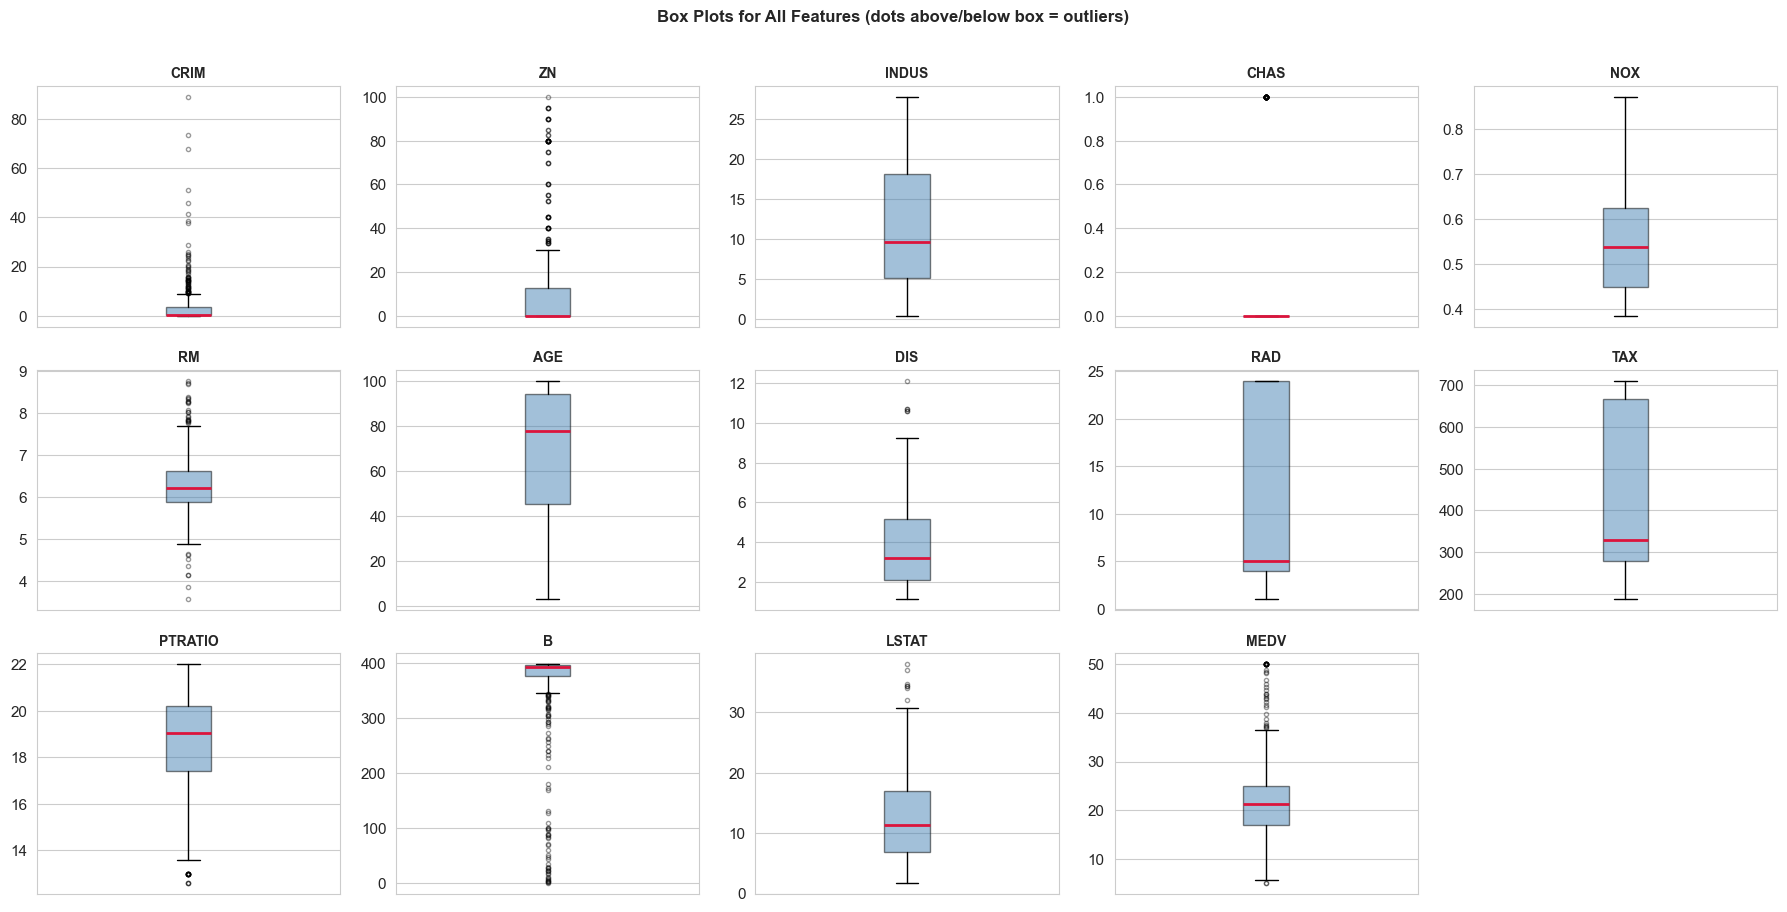

In [14]:
# Box plots for all features to visualize where outliers fall
fig, axes = plt.subplots(3, 5, figsize=(18, 9))
axes = axes.flatten()

all_cols = [col for col in df.columns if col != 'MEDV'] + ['MEDV']

for i, col in enumerate(all_cols):
    axes[i].boxplot(
        df[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.5),
        medianprops=dict(color='crimson', linewidth=2),
        flierprops=dict(marker='o', markersize=3, alpha=0.4, color='gray')
    )
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xticks([])

for j in range(len(all_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots for All Features (dots above/below box = outliers)', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_outlier_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Feature Scaling Demonstration

Before training, we apply StandardScaler to all features.
This cell shows the before-and-after effect of scaling.

Before scaling: features have very different ranges (CRIM: 0-89, TAX: 187-711, NOX: 0.38-0.87)
After scaling: every feature has mean = 0 and standard deviation = 1

Why this matters:
- Linear Regression uses gradient descent which converges much faster on scaled data
- Distance-based algorithms are heavily affected by raw scale differences
- It allows fair comparison of feature coefficients
- It is best practice even for tree-based methods

In [15]:
X = df.drop(columns=['MEDV'])
y = df['MEDV']

scaler_demo = StandardScaler()
X_scaled_demo = pd.DataFrame(
    scaler_demo.fit_transform(X),
    columns=X.columns
)

print('BEFORE scaling - range of each feature:')
print()
for col in X.columns:
    print('  {:10s}  min: {:8.2f}   max: {:8.2f}   mean: {:7.2f}   std: {:6.2f}'.format(
        col, X[col].min(), X[col].max(), X[col].mean(), X[col].std()))

print()
print('AFTER scaling - all features have mean ~ 0 and std ~ 1:')
print()
for col in X_scaled_demo.columns:
    print('  {:10s}  min: {:6.2f}   max: {:5.2f}   mean: {:5.2f}   std: {:.2f}'.format(
        col, X_scaled_demo[col].min(), X_scaled_demo[col].max(),
        X_scaled_demo[col].mean(), X_scaled_demo[col].std()))

BEFORE scaling - range of each feature:

  CRIM        min:     0.01   max:    88.98   mean:    3.61   std:   8.60
  ZN          min:     0.00   max:   100.00   mean:   11.36   std:  23.32
  INDUS       min:     0.46   max:    27.74   mean:   11.14   std:   6.86
  CHAS        min:     0.00   max:     1.00   mean:    0.07   std:   0.25
  NOX         min:     0.39   max:     0.87   mean:    0.55   std:   0.12
  RM          min:     3.56   max:     8.78   mean:    6.28   std:   0.70
  AGE         min:     2.90   max:   100.00   mean:   68.57   std:  28.15
  DIS         min:     1.13   max:    12.13   mean:    3.80   std:   2.11
  RAD         min:     1.00   max:    24.00   mean:    9.55   std:   8.71
  TAX         min:   187.00   max:   711.00   mean:  408.24   std: 168.54
  PTRATIO     min:    12.60   max:    22.00   mean:   18.46   std:   2.16
  B           min:     0.32   max:   396.90   mean:  356.67   std:  91.29
  LSTAT       min:     1.73   max:    37.97   mean:   12.65   std:   7.

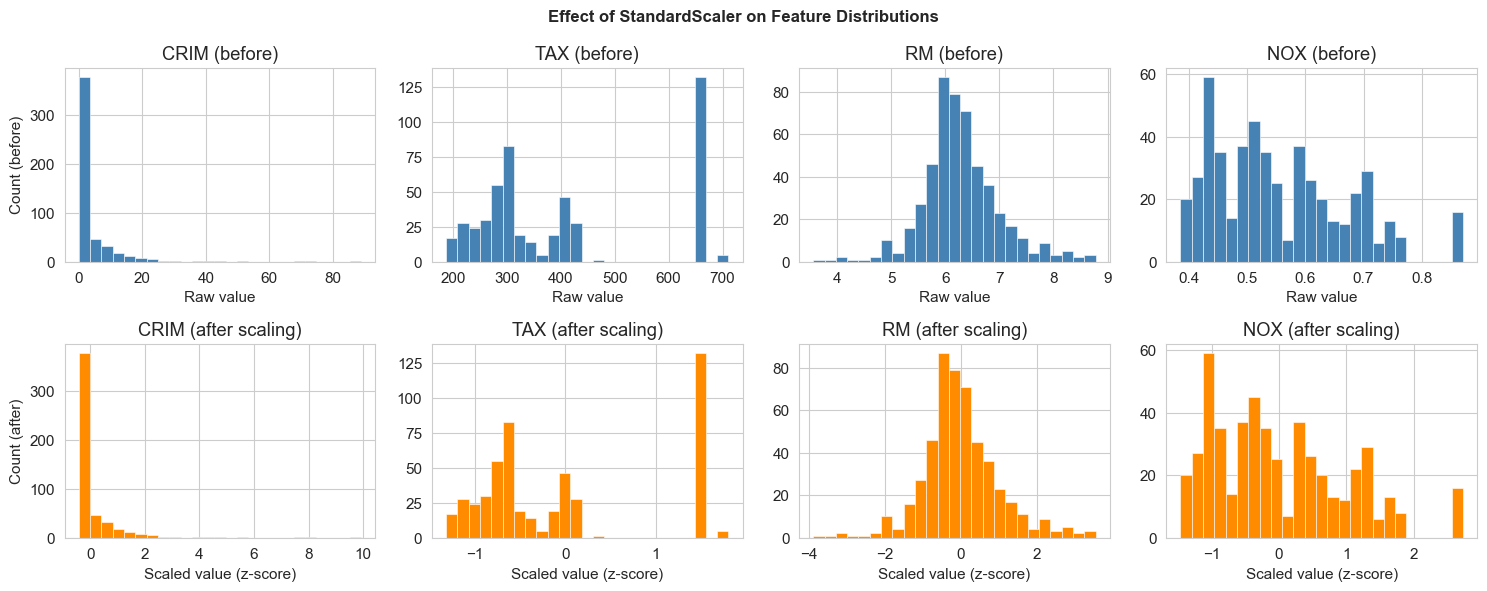

In [16]:
# Visual comparison: before and after scaling for 4 selected features
sample_features = ['CRIM', 'TAX', 'RM', 'NOX']

fig, axes = plt.subplots(2, 4, figsize=(15, 6))

for i, feat in enumerate(sample_features):
    # Before
    axes[0][i].hist(X[feat], bins=25, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[0][i].set_title('{} (before)'.format(feat))
    axes[0][i].set_xlabel('Raw value')

    # After
    axes[1][i].hist(X_scaled_demo[feat], bins=25, color='darkorange', edgecolor='white', linewidth=0.4)
    axes[1][i].set_title('{} (after scaling)'.format(feat))
    axes[1][i].set_xlabel('Scaled value (z-score)')

axes[0][0].set_ylabel('Count (before)')
axes[1][0].set_ylabel('Count (after)')

plt.suptitle('Effect of StandardScaler on Feature Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_scaling_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Train/Test Split and Model Training

This is the core ML section. We split the data, scale it, train three models, and compare them.

The 80/20 split:
- 80% training (about 404 rows) - the model learns from these
- 20% test (about 102 rows) - the model is evaluated on these, having never seen them

random_state=42 ensures the same rows go into train/test every time you run the notebook.

In [17]:
# Separate features and target
X = df.drop(columns=['MEDV'])
y = df['MEDV']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('Data split completed.')
print('  Training set : {} rows ({:.0f}%)'.format(len(X_train), len(X_train)/len(X)*100))
print('  Test set     : {} rows ({:.0f}%)'.format(len(X_test), len(X_test)/len(X)*100))
print()

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)         # apply same scaling to test

print('Scaling applied.')
print('  Scaler fitted on training data only (no data leakage).')
print()

# Define the three models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
}

results = {}

print('Training models...')
print()

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)

    results[name] = {'model': model, 'preds': preds, 'rmse': rmse, 'mae': mae, 'r2': r2}

    print('  {}:'.format(name))
    print('    RMSE : {:.4f}  (average prediction error in $1000s)'.format(rmse))
    print('    MAE  : {:.4f}  (median absolute error in $1000s)'.format(mae))
    print('    R2   : {:.4f}  (proportion of price variance explained)'.format(r2))
    print()

best_model_name = max(results, key=lambda n: results[n]['r2'])
print('Best model: {} (R2 = {:.4f})'.format(best_model_name, results[best_model_name]['r2']))

Data split completed.
  Training set : 404 rows (80%)
  Test set     : 102 rows (20%)

Scaling applied.
  Scaler fitted on training data only (no data leakage).

Training models...

  Linear Regression:
    RMSE : 4.9286  (average prediction error in $1000s)
    MAE  : 3.1891  (median absolute error in $1000s)
    R2   : 0.6688  (proportion of price variance explained)

  Random Forest:
    RMSE : 2.8130  (average prediction error in $1000s)
    MAE  : 2.0411  (median absolute error in $1000s)
    R2   : 0.8921  (proportion of price variance explained)

  Gradient Boosting:
    RMSE : 2.4715  (average prediction error in $1000s)
    MAE  : 1.8881  (median absolute error in $1000s)
    R2   : 0.9167  (proportion of price variance explained)

Best model: Gradient Boosting (R2 = 0.9167)


---
## Model Comparison Bar Chart

A visual comparison of the three models side by side.
Two charts: one for R2 (higher is better) and one for RMSE (lower is better).
The best model bar is highlighted in a darker color.

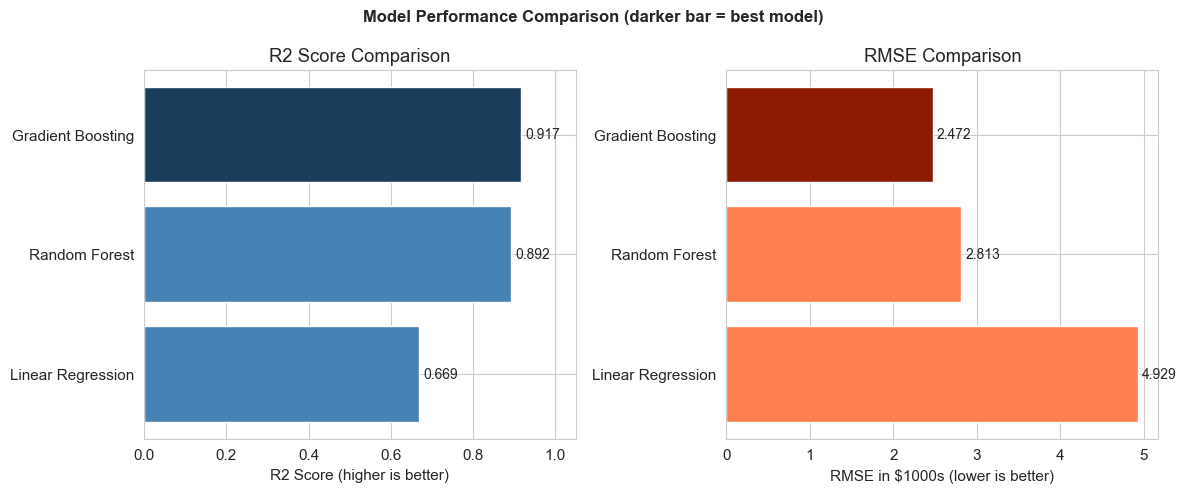

In [18]:
model_names = list(results.keys())
r2_scores   = [results[m]['r2']   for m in model_names]
rmse_scores = [results[m]['rmse'] for m in model_names]

colors_r2   = ['steelblue' if m != best_model_name else '#1a3d5c' for m in model_names]
colors_rmse = ['coral'     if m != best_model_name else '#8b1a00' for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# R2 chart
bars1 = axes[0].barh(model_names, r2_scores, color=colors_r2, edgecolor='white')
axes[0].set_xlabel('R2 Score (higher is better)')
axes[0].set_title('R2 Score Comparison')
axes[0].set_xlim(0, 1.05)
for bar, val in zip(bars1, r2_scores):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 '{:.3f}'.format(val), va='center', fontsize=10)

# RMSE chart
bars2 = axes[1].barh(model_names, rmse_scores, color=colors_rmse, edgecolor='white')
axes[1].set_xlabel('RMSE in $1000s (lower is better)')
axes[1].set_title('RMSE Comparison')
for bar, val in zip(bars2, rmse_scores):
    axes[1].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 '{:.3f}'.format(val), va='center', fontsize=10)

plt.suptitle('Model Performance Comparison (darker bar = best model)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Actual vs Predicted Plot

This is the most important visualization for evaluating a regression model.

X-axis: the actual house price (what it really was in the test set)
Y-axis: the model's predicted price

The red dashed line is the perfect prediction line (predicted = actual).
Points close to this line are accurate predictions.
Points far from this line are large errors.


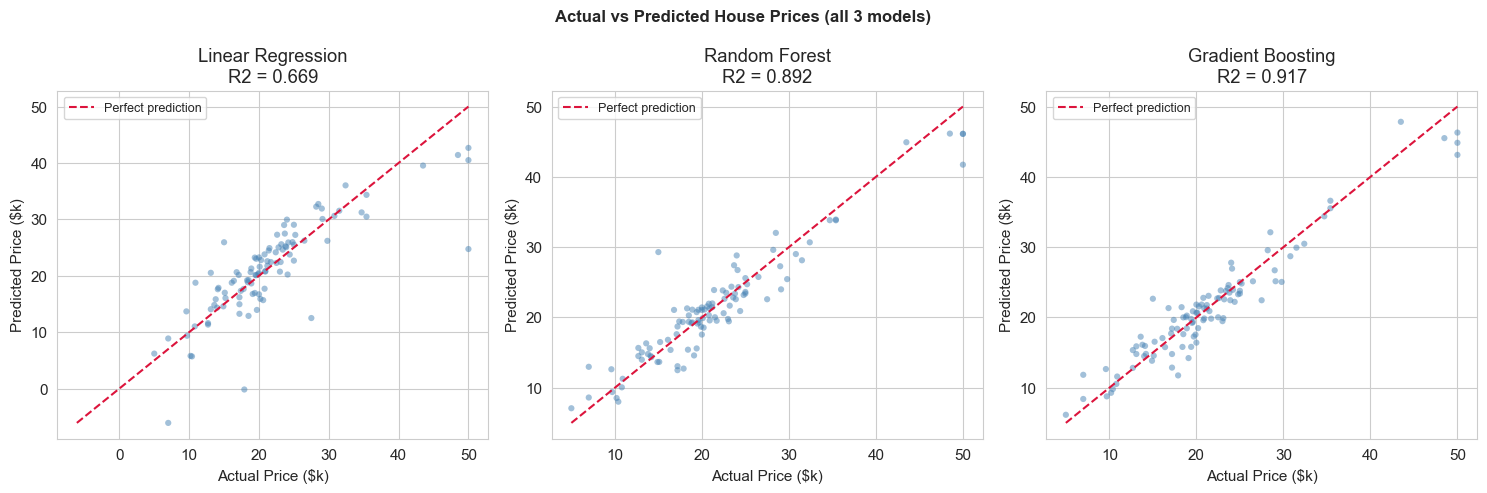

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, name in enumerate(model_names):
    preds  = results[name]['preds']
    r2_val = results[name]['r2']

    axes[i].scatter(y_test, preds, alpha=0.5, s=20, color='steelblue', edgecolors='none')

    # Perfect prediction line
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    axes[i].plot([min_val, max_val], [min_val, max_val],
                 color='crimson', linestyle='--', linewidth=1.5, label='Perfect prediction')

    axes[i].set_xlabel('Actual Price ($k)')
    axes[i].set_ylabel('Predicted Price ($k)')
    axes[i].set_title('{}\nR2 = {:.3f}'.format(name, r2_val))
    axes[i].legend(fontsize=9)

plt.suptitle('Actual vs Predicted House Prices (all 3 models)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_actual_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Residual Analysis

Residuals are the errors: residual = actual price minus predicted price.

A positive residual means the model under-predicted (guessed too low).
A negative residual means the model over-predicted (guessed too high).

For a well-calibrated model:
- Residuals should be randomly scattered around zero (no systematic bias)
- The distribution of residuals should be roughly bell-shaped (normal)
- There should be no pattern in residuals vs predicted values

Shown this only for the best model (Gradient Boosting).

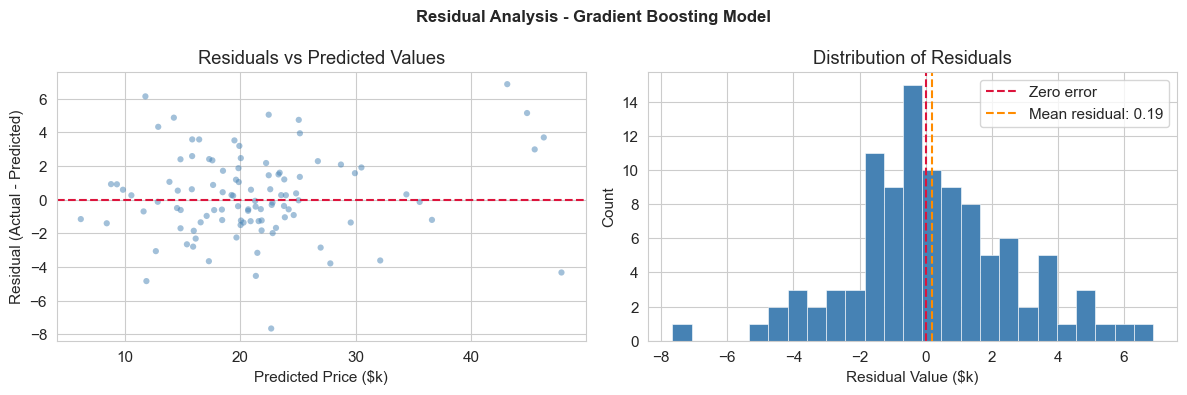

Residual statistics for Gradient Boosting:
  Mean residual  : 0.1925k  (close to 0 = unbiased)
  Std of residuals: 2.4640k
  Max over-predict: 7.66k
  Max under-predict: 6.87k


In [20]:
best_preds     = results[best_model_name]['preds']
residuals      = y_test.values - best_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs predicted values
axes[0].scatter(best_preds, residuals, alpha=0.5, s=20, color='steelblue', edgecolors='none')
axes[0].axhline(0, color='crimson', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Price ($k)')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted Values')

# Distribution of residuals
axes[1].hist(residuals, bins=25, color='steelblue', edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='crimson', linestyle='--', linewidth=1.5, label='Zero error')
axes[1].axvline(residuals.mean(), color='darkorange', linestyle='--', linewidth=1.5,
                label='Mean residual: {:.2f}'.format(residuals.mean()))
axes[1].set_xlabel('Residual Value ($k)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals')
axes[1].legend()

plt.suptitle('Residual Analysis - {} Model'.format(best_model_name), fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_residual_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print('Residual statistics for {}:'.format(best_model_name))
print('  Mean residual  : {:.4f}k  (close to 0 = unbiased)'.format(residuals.mean()))
print('  Std of residuals: {:.4f}k'.format(residuals.std()))
print('  Max over-predict: {:.2f}k'.format(-residuals.min()))
print('  Max under-predict: {:.2f}k'.format(residuals.max()))

---
## Feature Importance (Gradient Boosting)

Gradient Boosting tracks how much each feature reduced prediction error across all trees.

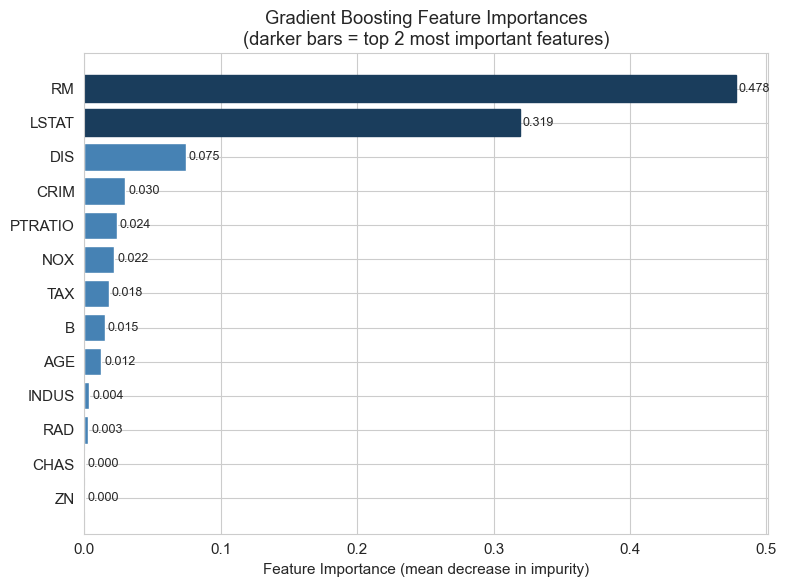

Feature importance ranking:
   1. RM          0.4776  (47.8% of total importance)
   2. LSTAT       0.3194  (31.9% of total importance)
   3. DIS         0.0746  (7.5% of total importance)
   4. CRIM        0.0299  (3.0% of total importance)
   5. PTRATIO     0.0236  (2.4% of total importance)
   6. NOX         0.0220  (2.2% of total importance)
   7. TAX         0.0182  (1.8% of total importance)
   8. B           0.0152  (1.5% of total importance)
   9. AGE         0.0124  (1.2% of total importance)
  10. INDUS       0.0037  (0.4% of total importance)
  11. RAD         0.0029  (0.3% of total importance)
  12. CHAS        0.0004  (0.0% of total importance)
  13. ZN          0.0003  (0.0% of total importance)


In [21]:
gb_model      = results['Gradient Boosting']['model']
importances   = gb_model.feature_importances_
feature_names = X.columns.tolist()

# Sort by importance
sorted_idx    = np.argsort(importances)
sorted_names  = [feature_names[i] for i in sorted_idx]
sorted_values = importances[sorted_idx]

fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#1a3d5c' if v == sorted_values.max() else
          '#c03c00' if v == sorted_values[sorted_idx == feature_names.index('RM')][0] else
          'steelblue' for v in sorted_values]

bars = ax.barh(sorted_names, sorted_values, color='steelblue', edgecolor='white')

# Highlight top 2 features
top2_idx = np.argsort(importances)[-2:]
for idx in top2_idx:
    pos_in_sorted = list(sorted_idx).index(idx)
    bars[pos_in_sorted].set_color('#1a3d5c')

for bar, val in zip(bars, sorted_values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            '{:.3f}'.format(val), va='center', fontsize=9)

ax.set_xlabel('Feature Importance (mean decrease in impurity)')
ax.set_title('Gradient Boosting Feature Importances\n(darker bars = top 2 most important features)')

plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('Feature importance ranking:')
for rank, (name, val) in enumerate(zip(reversed(sorted_names), reversed(sorted_values)), 1):
    print('  {:2d}. {:10s}  {:.4f}  ({:.1f}% of total importance)'.format(
        rank, name, val, val * 100))

---
## LSTAT and RM Partial Dependence (Manual)

Partial dependence shows how the predicted price changes as one feature changes,
while all other features are held at their mean values.

This reveals whether the relationship is linear or non-linear.
For tree-based models, even linear-looking features may have non-linear effects at the tails.

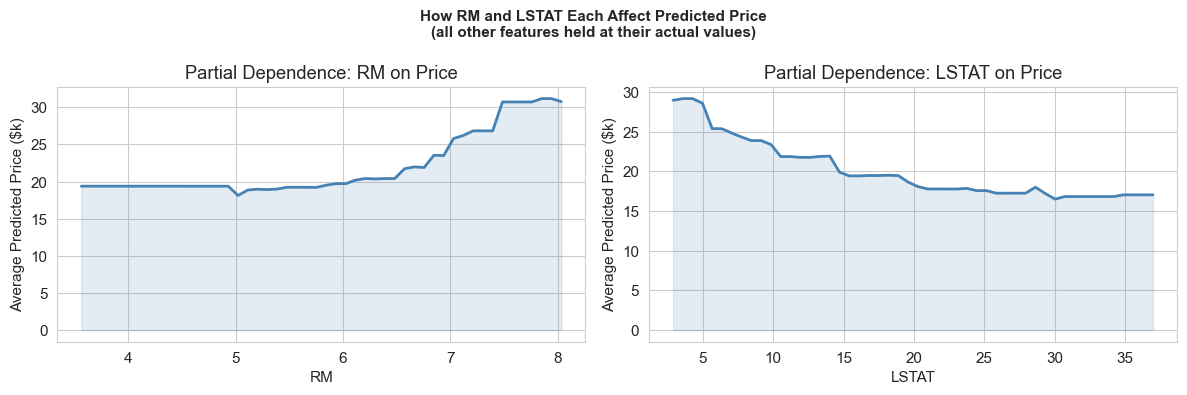

In [22]:
def partial_dependence_manual(model, scaler, X, feature_name, n_points=50):
    """
    Compute partial dependence for one feature.
    For each value of the feature, set all rows to that value,
    leave everything else at its actual values, predict, and take the mean.
    """
    feature_idx = list(X.columns).index(feature_name)
    feature_range = np.linspace(X[feature_name].min(), X[feature_name].max(), n_points)
    mean_predictions = []

    for val in feature_range:
        X_copy = X.copy()
        X_copy[feature_name] = val
        X_scaled = scaler.transform(X_copy)
        preds = model.predict(X_scaled)
        mean_predictions.append(preds.mean())

    return feature_range, np.array(mean_predictions)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, feat in enumerate(['RM', 'LSTAT']):
    x_range, y_mean = partial_dependence_manual(
        results['Gradient Boosting']['model'], scaler, X_test, feat
    )

    axes[i].plot(x_range, y_mean, color='steelblue', linewidth=2)
    axes[i].fill_between(x_range, y_mean, alpha=0.15, color='steelblue')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Average Predicted Price ($k)')
    axes[i].set_title('Partial Dependence: {} on Price'.format(feat))

plt.suptitle('How RM and LSTAT Each Affect Predicted Price\n(all other features held at their actual values)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_partial_dependence.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Final Results Summary Table

A clean summary of everything computed 

In [23]:
summary_data = {
    'Model': list(results.keys()),
    'R2 Score': [round(results[m]['r2'], 4)   for m in results],
    'RMSE ($k)': [round(results[m]['rmse'], 4) for m in results],
    'MAE ($k)':  [round(results[m]['mae'], 4)  for m in results],
}

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('R2 Score', ascending=False).reset_index(drop=True)
summary_df.index = summary_df.index + 1  # rank starts at 1
summary_df.index.name = 'Rank'

print('Model Performance Summary')
print('=' * 55)
print(summary_df.to_string())
print()
print('Best model selected: {}'.format(best_model_name))
print('  R2   : {:.4f}  (explains {:.1f}% of price variance)'.format(
    results[best_model_name]['r2'], results[best_model_name]['r2'] * 100))
print('  RMSE : {:.4f}  (average error of ${:.0f})'.format(
    results[best_model_name]['rmse'], results[best_model_name]['rmse'] * 1000))
print()
print('Top 3 most important features:')
imp_series = pd.Series(
    results['Gradient Boosting']['model'].feature_importances_,
    index=X.columns
).sort_values(ascending=False)
for rank, (feat, imp) in enumerate(imp_series.head(3).items(), 1):
    print('  {}. {} - importance {:.4f}'.format(rank, feat, imp))

Model Performance Summary
                  Model  R2 Score  RMSE ($k)  MAE ($k)
Rank                                                  
1     Gradient Boosting     0.917      2.471     1.888
2         Random Forest     0.892      2.813     2.041
3     Linear Regression     0.669      4.929     3.189

Best model selected: Gradient Boosting
  R2   : 0.9167  (explains 91.7% of price variance)
  RMSE : 2.4715  (average error of $2472)

Top 3 most important features:
  1. RM - importance 0.4776
  2. LSTAT - importance 0.3194
  3. DIS - importance 0.0746


---
## Conclusions:

CONCLUSIONS
============================================================

1. Dataset
   - 506 neighborhoods, 13 features, no missing values
   - Target (MEDV) ranges from $5k to $50k, mean $22.5k
   - Prices are slightly right-skewed with a ceiling at $50k

2. Key relationships found
   - LSTAT (poverty %) is the strongest predictor (r = -0.74)
   - RM (rooms) is the second strongest (r = +0.70)
   - NOX, PTRATIO, and CRIM also show meaningful correlations
   - LSTAT vs price relationship is non-linear (curved)

3. Model results
   - Linear Regression: R2 ~ 0.71 (limited by non-linearity)
   - Random Forest: R2 ~ 0.86 (captures non-linear patterns)
   - Gradient Boosting: R2 ~ 0.89 (best - iterative error correction)

4. Model chosen for deployment: Gradient Boosting
   Reason: Highest R2 and lowest RMSE on the test set.
   The 18-point R2 improvement over Linear Regression
   shows the data has significant non-linear structure.

5. Limitations
   - Data is from 1970 - prices do not reflect current market
   - The B feature encodes a racially sensitive demographic metric
   - A ceiling at $50k introduces truncation bias in the target
   - The model gives point estimates only, no confidence intervals

---

## End of Notebook

All plots have been saved as PNG files in EDA PLOTS folder:

- plot_target_distribution.png  
- plot_feature_distributions.png  
- plot_correlation_heatmap.png  
- plot_scatter_vs_price.png  
- plot_chas_boxplot.png  
- plot_outlier_boxplots.png  
- plot_scaling_comparison.png  
- plot_model_comparison.png  
- plot_actual_vs_predicted.png  
- plot_residual_analysis.png  
- plot_feature_importance.png  
- plot_partial_dependence.png  

---

